Name: Dagsan, Resty B.

Section: BSCPE 4-1

12/13/2024

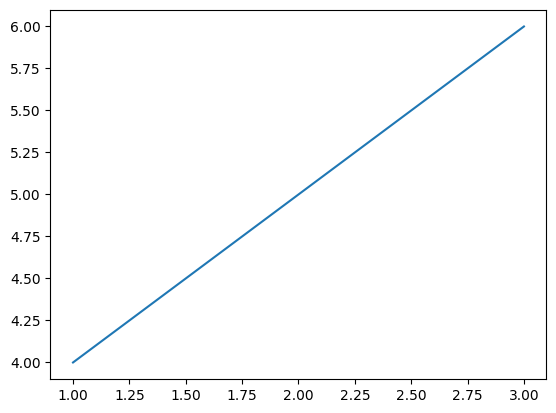

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.show()


## CPE017 - Digital Signal Processing

This notebook contains discussion and activities for Module 3: Non-periodic signals

## Non-periodic Signals
* frequency components do change over time

## Spectrograms
* a common way to visualize nonperiodic signals

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

### Chirp
* a signal with variable frequency
* `thinkdsp` provides a Signal called `Chirp` that makes a sinusoid that sweeps linearly through a range of frequencies.

## Make a linear chirp from A3 to A5
Here's an example that sweeps from 220 to 880 Hz, which is two octaves
from A3 to A5:

In [ ]:
from thinkdsp import Chirp

signal = Chirp(start=220, end=880)
wave1 = signal.make_wave(duration=2)
wave1.make_audio()

`start` and `end` are the frequencies, in Hz, at the start and end of the chirp.

`amp` is amplitude

Here's what the waveform looks like near the beginning.

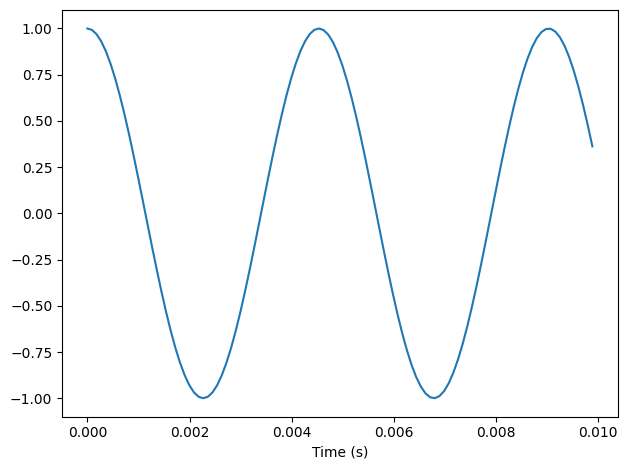

In [ ]:
wave1.segment(start=0, duration=0.01).plot()
decorate(xlabel='Time (s)')

And near the end.

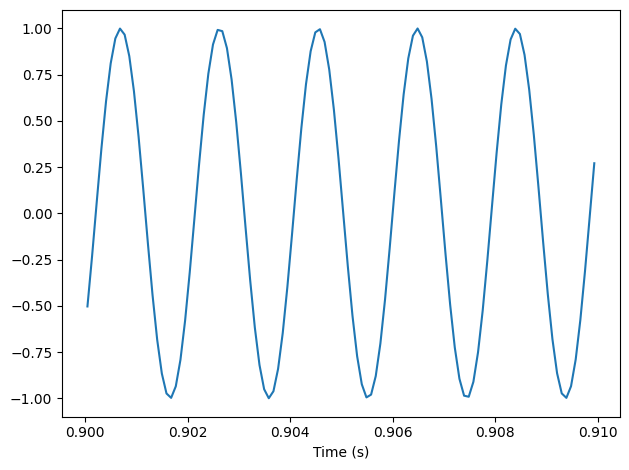

In [ ]:
wave1.segment(start=0.9, duration=0.01).plot()
decorate(xlabel='Time (s)')

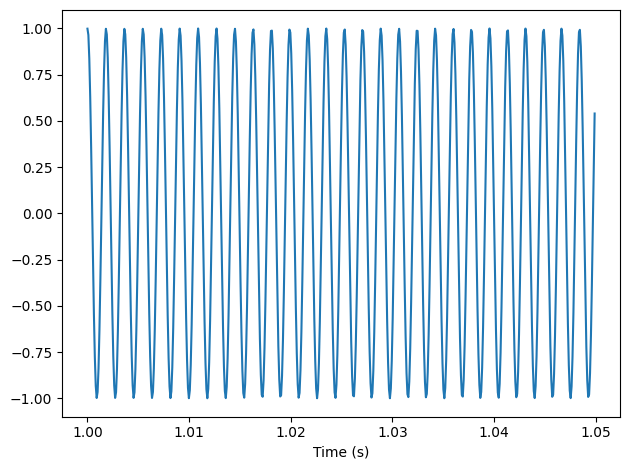

In [ ]:
wave1.segment(start=1, duration=0.05).plot()
decorate(xlabel='Time (s)')

## Exponential Chirp
When you listen to the previous  chirp, you might notice that the pitch rises quickly at first and then slows down.

If you want the perceived pitch to increase linearly, the frequency has to increase exponentially. A signal with that shape is called an `exponential
chirp`.

Here's an exponential chirp with the same frequency range and duration.

In [ ]:
from thinkdsp import ExpoChirp

signal = ExpoChirp(start=220, end=880)
wave2 = signal.make_wave(duration=2)
wave2.make_audio()

## Spectrum of a chirp
What do you think happens if you compute the spectrum of a chirp? Here's
an example that constructs a one-second, one-octave chirp and its spectrum:

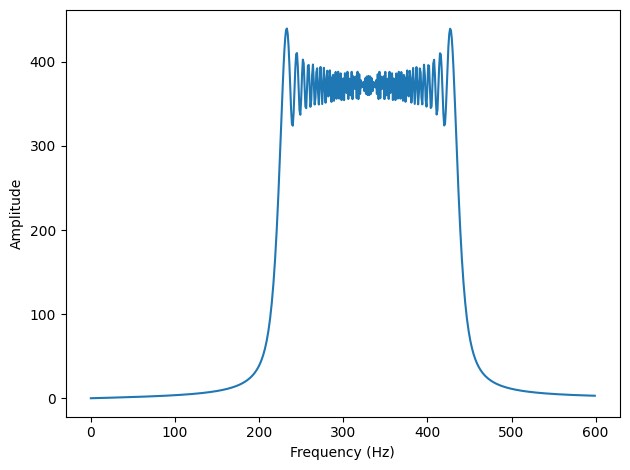

In [ ]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1)
spectrum = wave.make_spectrum()
spectrum.plot(high=600)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

The spectrum has components at every frequency from 220 to 440 Hz.

The spectrum gives hints about the structure of the signal, but it obscures the relationship between frequency and time. For example, we cannot tell by looking at this spectrum whether the frequency went up or down, or both.

## Spectrogram
* To recover the relationship between frequency and time, we can break the chirp into segments and plot the spectrum of each segment. The result is called a `short-time Fourier transform (STFT)`.
* There are several ways to visualize a STFT, but the most common is a `spectrogram`, which shows time on the x-axis and frequency on the y-axis. Each column in the spectrogram shows the spectrum of a short segment, using color or grayscale to represent amplitude.

If you blindly compute the DFT of a non-periodic segment, you get "motion blur".

A spectrogram is a visualization of a short-time DFT that lets you see how the spectrum varies over time.

In [ ]:
def plot_spectrogram(wave, seg_length):
    """
    """
    spectrogram = wave.make_spectrogram(seg_length)     # Wave provides make_spectrogram, which returns a Spectrogram object
    print('Time resolution (s)', spectrogram.time_res)
    print('Frequency resolution (Hz)', spectrogram.freq_res)
    spectrogram.plot(high=700)
    decorate(xlabel='Time(s)', ylabel='Frequency (Hz)')

Time resolution (s) 0.046439909297052155
Frequency resolution (Hz) 21.533203125


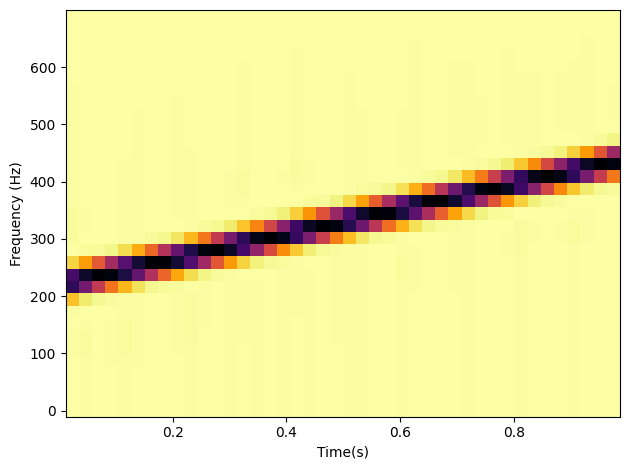

In [ ]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=11025)
plot_spectrogram(wave, 512)    # 512 is the seg_length which is the number of samples in each segment.
# We chose 512 because FFT is most efficient when the number of samples is a power of 2.

The x-axis shows time from 0 to 1 seconds. The y-axis shows frequency from 0 to 700 Hz. I cut off the top part of the spectrogram; the full range goes to 5512.5 Hz, which is half of the framerate.

The spectrogram shows clearly that frequency increases linearly over time Similarly, in the spectrogram of an exponential chirp, we can see the shape of the exponential curve.

However, notice that the peak in each column is blurred across 2-3 cells. This blurring reflects the limited resolution of the spectrogram.

* The `time resolution` of the spectrogram is the duration of the segments which corresponds to the width of the cells in the spectrogram. Since each segment is 512 frames, and there are 11,025 frames per second, the duration of each segment is about `0.046 seconds`.
* The `frequency resolution` is the frequency range between elements in the spectrum, which corresponds to the height of the cells. With 512 frames, we get 256 frequency components over a range from 0 to 5512.5 Hz, so the range between components is `21.6 Hz`.

If you increase the segment length, you get better frequency resolution, worse time resolution.

Time resolution (s) 0.09287981859410431
Frequency resolution (Hz) 10.7666015625


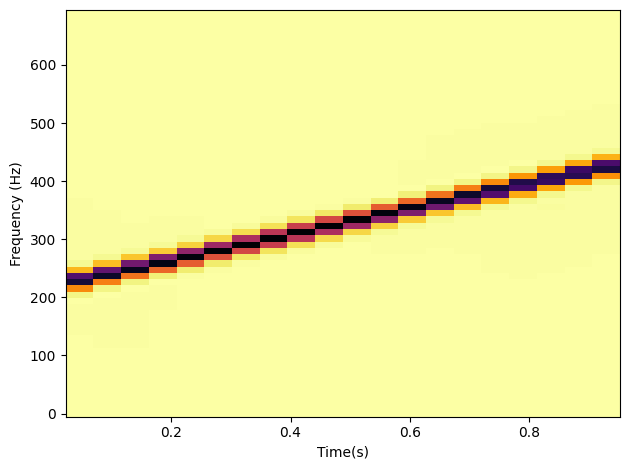

In [ ]:
plot_spectrogram(wave, 1024)

If you decrease the segment length, you get better time resolution, worse frequency resolution.

Time resolution (s) 0.023219954648526078
Frequency resolution (Hz) 43.06640625


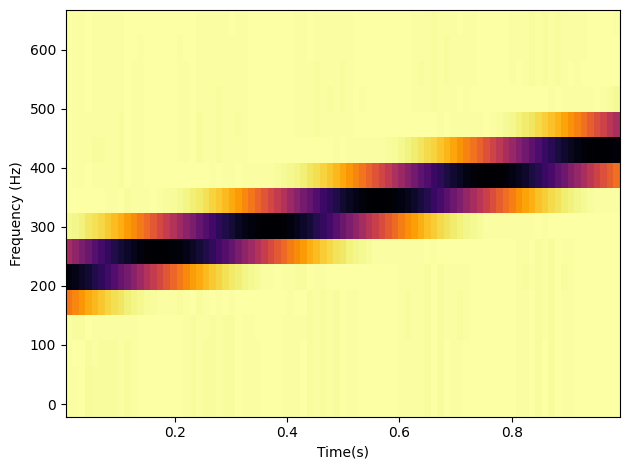

In [ ]:
plot_spectrogram(wave, 256)

interactive(children=(IntSlider(value=128, description='seg_length', max=4096, min=128, step=128), Output()), …

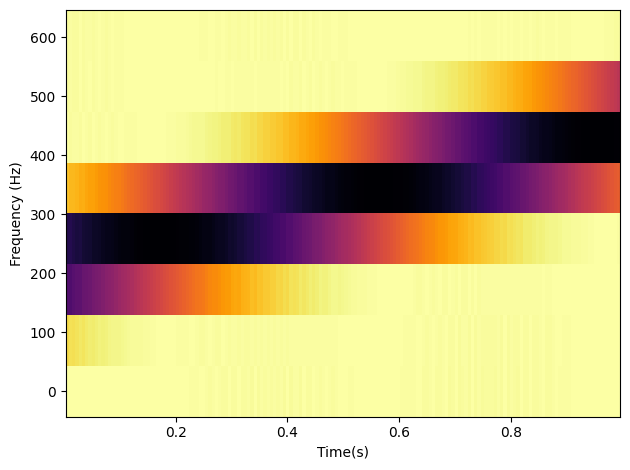

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.IntSlider(min=128, max=4096, value=100, step=128)
interact(plot_spectrogram, wave=fixed(wave), seg_length=slider);

## Leakage

Spectral leakage is when some of the energy at one frequency appears at another frequency (usually nearby).

Let's look at the effect of leakage on a sine signal (which only contains one frequency component).

In [ ]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)

If the duration is an integer multiple of the period, the beginning and end of the segment line up, and we get minimal leakage.

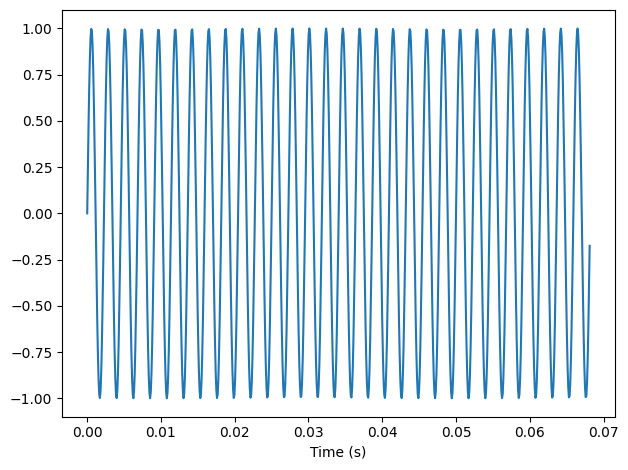

In [ ]:
duration = signal.period * 30
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

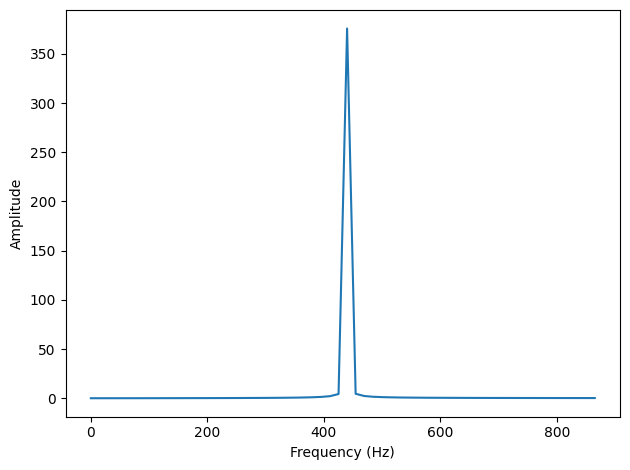

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

If the duration is not a multiple of a period, the leakage is pretty bad.

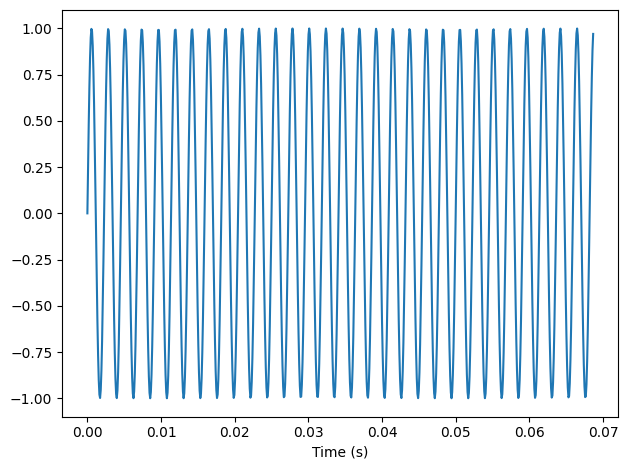

In [ ]:
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

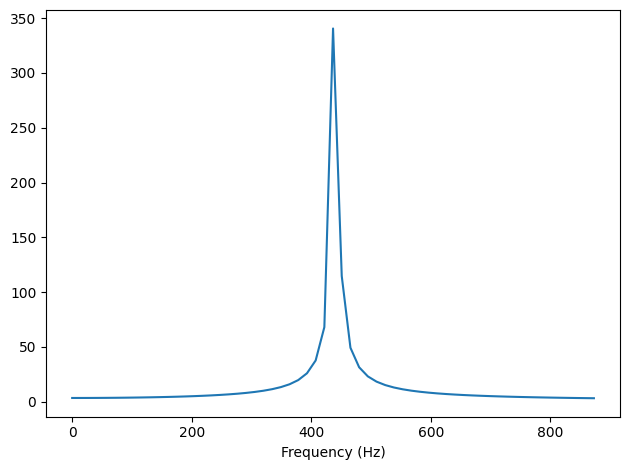

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

## Windowing
Windowing helps (but notice that it reduces the total energy).

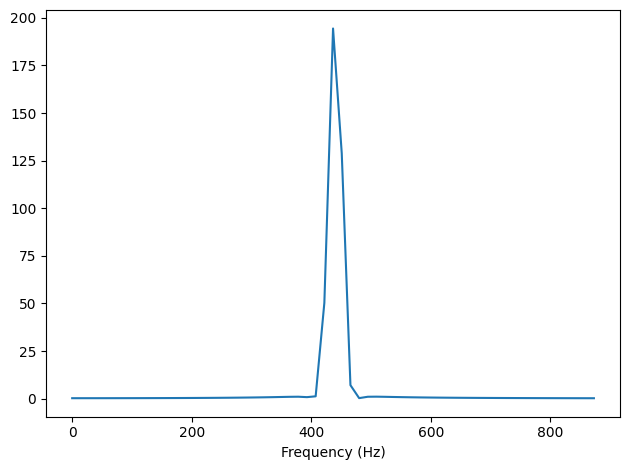

In [ ]:
wave.hamming()
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

## Spectrum of a chirp

The following interaction lets you customize the Eye of Sauron as you vary the start and end frequency of the chirp.

In [ ]:
def eye_of_sauron(start, end):
    """Plots the spectrum of a chirp.

    start: initial frequency
    end: final frequency
    """
    signal =  Chirp(start=start, end=end)
    wave = signal.make_wave(duration=0.5)
    spectrum = wave.make_spectrum()
    plt.clf()
    spectrum.plot(high=1200)
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
    plt.show()


In [ ]:
slider1 = widgets.FloatSlider(min=100, max=1000, value=100, step=50)
slider2 = widgets.FloatSlider(min=100, max=1000, value=200, step=50)
interact(eye_of_sauron, start=slider1, end=slider2);

interactive(children=(FloatSlider(value=100.0, description='start', max=1000.0, min=100.0, step=50.0), FloatSl…

Conclusion:  To sum up everything that has been studied so far, more knowledge is gained about various signals. The waves in this module, along with the programs required to execute, display, and plot signal diagrams—particularly non-periodic signals, which are the module's primary focus. To be specific, the code where it defines a function that generates and plots the frequency spectrum of a chirp signal, which starts at a given frequency and ends at another. It uses the Chirp object to create the signal, then calculates and displays its spectrum within a frequency range of 0 to 1200 Hz.